# Curso: Aplicações de Aprendizado de Máquina em Sistemas Embarcados

## Atividade Final 

Aluno: Marcos Cabanas Esteves

## Objetivos desta atividade
Treinar um modelo de reconhecimento de atividades humanas (HAR) a partir de dados de acelerômetro e convertê-lo para um formato compatível com execução na borda, com foco em dispositivos móveis como smartphones.

In [32]:
# Bibliotecas
from pathlib import Path
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy import stats
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn import metrics
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42

# Leitura do arquivo (sem dependência de Google Colab)
# Ajuste o caminho para onde está o arquivo WISDM no seu computador.
file_path = Path('./dataset/WISDM_ar_v1.1_raw.txt')

if not file_path.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado em {file_path.resolve()}. Ajuste o caminho em file_path.'
    )

# O dataset tem linhas quebradas e a última coluna precisa de limpeza
columns = ['user','activity','timestamp', 'x-axis', 'y-axis', 'z-axis']
data = []

with open(file_path, encoding='utf-8') as f:
    for line in f:
        try:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            if len(parts) < 6:
                continue
            user = int(parts[0])
            activity = parts[1]
            timestamp = int(parts[2])
            x = float(parts[3])
            y = float(parts[4])
            z = float(parts[5].split(';')[0])  # remove o ;
            data.append([user, activity, timestamp, x, y, z])
        except:
            continue

df = pd.DataFrame(data, columns=columns)

In [33]:
# Visualizar as primeiras linhas
print(df.head())
print(df.shape)
print(df.info)

   user activity       timestamp    x-axis     y-axis    z-axis
0    33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1    33  Jogging  49106062271000  5.012288  11.264028  0.953424
2    33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3    33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4    33  Jogging  49106332290000 -1.184970  12.108489  7.205164
(1098203, 6)
<bound method DataFrame.info of          user activity        timestamp    x-axis     y-axis    z-axis
0          33  Jogging   49105962326000 -0.694638  12.680544  0.503953
1          33  Jogging   49106062271000  5.012288  11.264028  0.953424
2          33  Jogging   49106112167000  4.903325  10.882658 -0.081722
3          33  Jogging   49106222305000 -0.612916  18.496431  3.023717
4          33  Jogging   49106332290000 -1.184970  12.108489  7.205164
...       ...      ...              ...       ...        ...       ...
1098198    19  Sitting  131623331483000  9.000000  -1.570000  1.690000
109

Text(0, 0.5, 'Frequency')

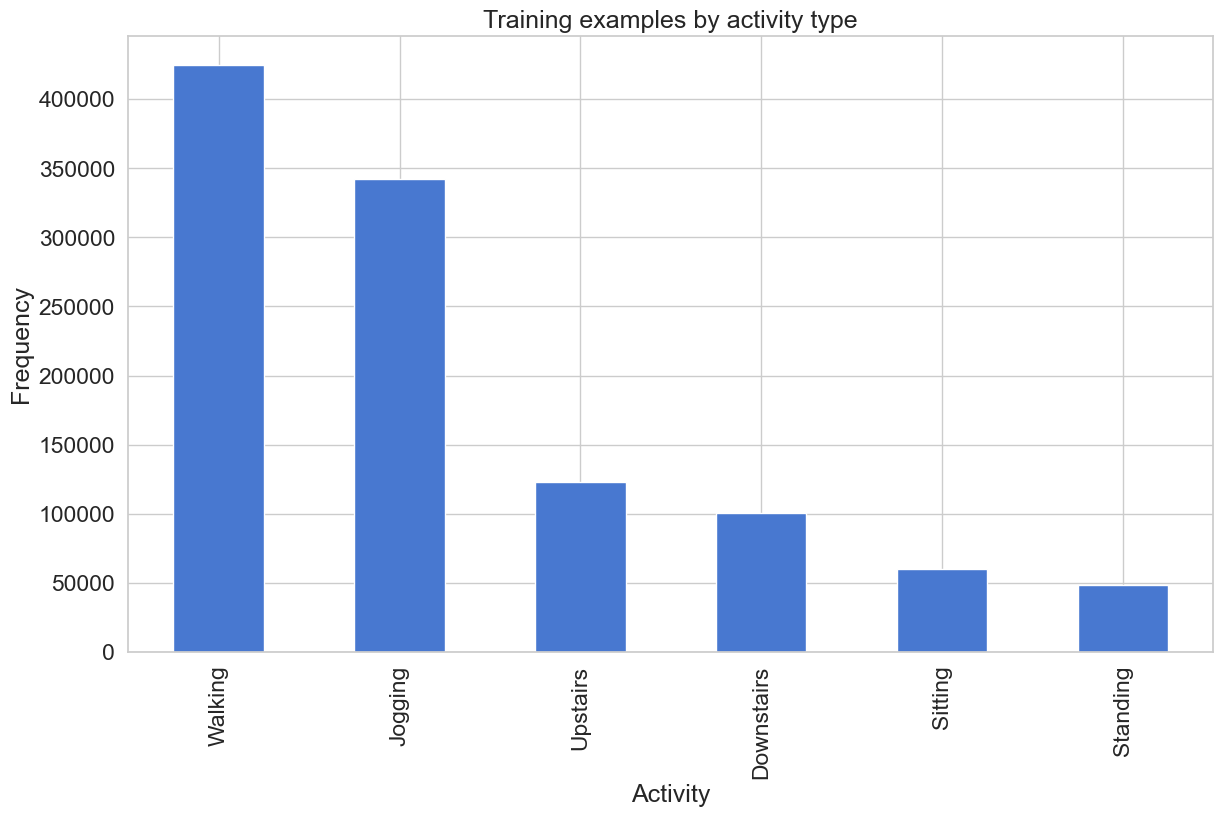

In [34]:
ax = df['activity'].value_counts().plot(kind='bar', title='Training examples by activity type')
ax.set_xlabel("Activity")
ax.set_ylabel("Frequency")


In [35]:
from scipy import stats
import numpy as np
import pandas as pd

N_TIME_STEPS = 200
N_FEATURES = 3
step = 20
segments = []
labels = []

for i in range(0, len(df) - N_TIME_STEPS, step):
    xs = df['x-axis'].values[i: i + N_TIME_STEPS]
    ys = df['y-axis'].values[i: i + N_TIME_STEPS]
    zs = df['z-axis'].values[i: i + N_TIME_STEPS]

    # Segmento no formato (200, 3)
    segment = np.array([xs, ys, zs]).T
    segments.append(segment)

    # Atividade predominante (label mais comum na janela)
    window_activities = df['activity'][i: i + N_TIME_STEPS]
    values, counts = np.unique(window_activities, return_counts=True)
    label = values[np.argmax(counts)]
    labels.append(label)

# Converter listas para arrays
segments = np.asarray(segments, dtype=np.float32)  # shape: (n, 200, 3)

# One-hot encoding dos labels
labels = pd.get_dummies(labels)                    # DataFrame com colunas = classes
labels = np.asarray(labels, dtype=np.float32)      # shape: (n, n_classes)


**Verificações:**

In [36]:
print("Formato dos segmentos:", segments.shape)
print("Formato dos labels (one-hot):", labels.shape)

Formato dos segmentos: (54901, 200, 3)
Formato dos labels (one-hot): (54901, 6)


In [37]:
pd.DataFrame(segments[1000], columns=['x', 'y', 'z']).head()


,x,y,z
0,2.53,13.80,-0.994285
1,-6.24,8.31,-1.729784
2,-3.41,8.73,-4.862464
3,1.69,15.24,-3.214402
4,7.70,11.73,-1.525479


In [38]:
idx = 1000     # Índice desejado
# Visualizar o segmento como DataFrame
pd.DataFrame(segments[idx], columns=['x', 'y', 'z'])

# Visualizar o label (one-hot)
print("One-hot label:", labels[idx])

# Obter o índice da classe (posição do 1)
class_index = np.argmax(labels[idx])

# Opcional: reconstruir o nome da classe original
label_names = pd.get_dummies(df['activity']).columns.tolist()

print("Classe correspondente:", label_names[class_index])

One-hot label: [0. 0. 0. 0. 0. 1.]
Classe correspondente: Walking


In [39]:
class_index

5

In [40]:
df['activity'].value_counts()

activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64

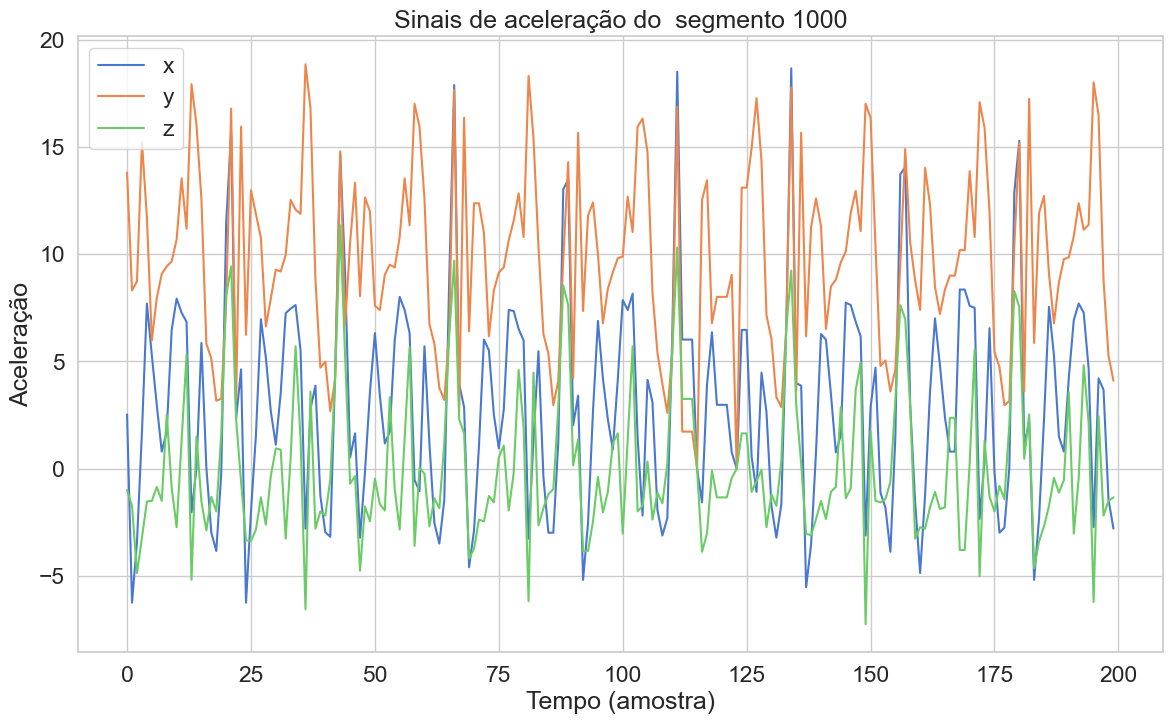

In [41]:
import matplotlib.pyplot as plt

plt.plot(segments[1000])
plt.title("Sinais de aceleração do  segmento 1000")
plt.xlabel("Tempo (amostra)")
plt.ylabel("Aceleração")
plt.legend(["x", "y", "z"])
plt.show()


# Treinamento do Modelo

In [42]:
# Imports e configuração
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle
import numpy as np

# Etapa 1 – Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    segments, labels, test_size=0.2, random_state=42, stratify=labels)

# Etapa 2 – Parâmetros
N_CLASSES = y_train.shape[1]
N_TIME_STEPS = X_train.shape[1]
N_FEATURES = X_train.shape[2]
N_HIDDEN_UNITS = 64
L2_LOSS = 0.0015
LEARNING_RATE = 0.0025
N_EPOCHS = 50



Epoch 1/50


/Users/marcos/.pyenv/versions/3.12.10/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6523 - loss: 1.2350
Epoch 1: val_loss improved from None to 0.63497, saving model to ./checkpoint/best_model.h5



Epoch 1: finished saving model to ./checkpoint/best_model.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7405 - loss: 0.9470 - val_accuracy: 0.8199 - val_loss: 0.6350
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.8207 - loss: 0.6165
Epoch 2: val_loss improved from 0.63497 to 0.45316, saving model to ./checkpoint/best_model.h5



Epoch 2: finished saving model to ./checkpoint/best_model.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 952ms/step - accuracy: 0.8300 - loss: 0.5811 - val_accuracy: 0.8614 - val_loss: 0.4532
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.8504 - loss: 0.4968
Epoch 3: val_loss improved from 0.45316 to 0.40936, saving model to ./checkpoint/best_model.h5


...


Epoch 9: finished saving model to ./checkpoint/best_model.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 948ms/step - accuracy: 0.9644 - loss: 0.1806 - val_accuracy: 0.9726 - val_loss: 0.1527
Epoch 10/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.9719 - loss: 0.1541
Epoch 10: val_loss improved from 0.15266 to 0.14224, saving model to ./checkpoint/best_model.h5



Epoch 10: finished saving model to ./checkpoint/best_model.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 968ms/step - accuracy: 0.9720 - loss: 0.1485 - val_accuracy: 0.9706 - val_loss: 0.1422
Epoch 11/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.9706 - loss: 0.1473
Epoch 11: val_loss improved from 0.14224 to 0.11560, saving model to ./checkpoint/best_model.h5



Epoch 11: finished saving model to ./checkpoint/best_model.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9735 - loss: 0.1391 - val_accuracy: 0.9810 - val_loss: 0.1156
Epoch 12/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.9796 - loss: 0.1198
Epoch 12: val_loss did not improve from 0.11560
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 949ms/step - accuracy: 0.9783 - loss: 0.1244 - val_accuracy: 0.9749 - val_loss: 0.1330
Epoch 13/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.9727 - loss: 0.1413
Epoch 13: val_loss did not improve from 0.11560
86/86 ━━━━━━━━━━━━━━━━━━━━ 78s 899ms/step - accuracy: 0.9736 - loss: 0.1369 - val_accuracy: 0.9771 - val_loss: 0.1170
Epoch 14/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.9793 - loss: 0.1123
Epoch 14: val_loss improved from 0.11560 to 0.10311, saving model to ./checkpoint/best_model.h5



Epoch 14: finished saving model to ./checkpoint/best_model.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 85s 941ms/step - accuracy: 0.9793 - loss: 0.1124 - val_accuracy: 0.9801 - val_loss: 0.1031
Epoch 15/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.9803 - loss: 0.1048
Epoch 15: val_loss improved from 0.10311 to 0.09431, saving model to ./checkpoint/best_model.h5



Epoch 15: finished saving model to ./checkpoint/best_model.h5
86/86 ━━━━━━━━━━━━━━━━━━━━ 80s 931ms/step - accuracy: 0.9806 - loss: 0.1040 - val_accuracy: 0.9850 - val_loss: 0.0943
Epoch 16/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.9816 - loss: 0.1007
Epoch 16: val_loss did not improve from 0.09431
86/86 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9811 - loss: 0.1036 - val_accuracy: 0.9813 - val_loss: 0.1035
Epoch 17/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.9810 - loss: 0.1012
Epoch 17: val_loss did not improve from 0.09431
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 940ms/step - accuracy: 0.9806 - loss: 0.1062 - val_accuracy: 0.9678 - val_loss: 0.1425
Epoch 18/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.9613 - loss: 0.1665
Epoch 18: val_loss did not improve from 0.09431
86/86 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9686 - loss: 0.1442 - val_accuracy: 0.9768 - val_loss: 0.1178
Epoch 19/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 906ms/step - accuracy: 0

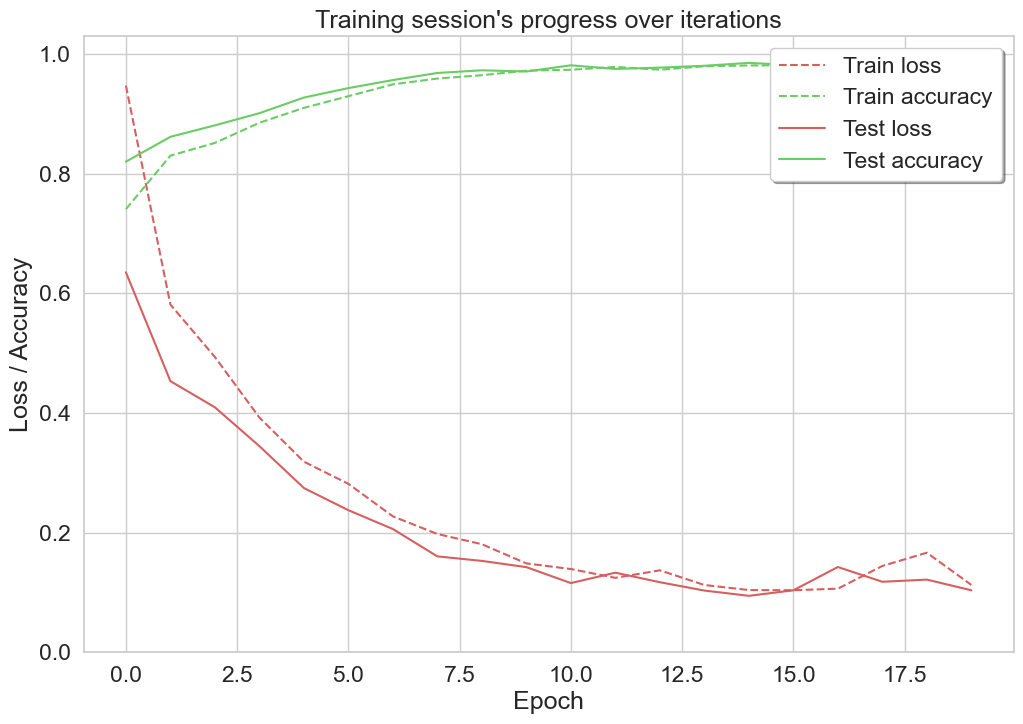

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Caminho para salvar o melhor modelo
checkpoint_path = './checkpoint/best_model.h5'

# Callbacks: EarlyStopping e ModelCheckpoint
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

model = Sequential([
    LSTM(N_HIDDEN_UNITS, return_sequences=True, input_shape=(N_TIME_STEPS, N_FEATURES),
         kernel_regularizer=l2(L2_LOSS)),
    LSTM(N_HIDDEN_UNITS, kernel_regularizer=l2(L2_LOSS)),
    Dense(64, activation='relu', kernel_regularizer=l2(L2_LOSS)),
    Dropout(0.3),  # reduzido de 0.5 para 0.3
    Dense(N_CLASSES, activation='softmax', name="y_")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train, y_train,
    epochs=N_EPOCHS,
    batch_size=512,  # reduzido de 1024
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

# Avaliação
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nFinal results - Accuracy: {acc:.4f} | Loss: {loss:.4f}')

# Previsões e salvamento
predictions = model.predict(X_test)
pickle.dump(predictions, open("predictions.p", "wb"))
pickle.dump(history.history, open("history.p", "wb"))
model.save('./checkpoint/final_model.h5')

# Curva de aprendizado
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'], "r--", label="Train loss")
plt.plot(history.history['accuracy'], "g--", label="Train accuracy")
plt.plot(history.history['val_loss'], "r-", label="Test loss")
plt.plot(history.history['val_accuracy'], "g-", label="Test accuracy")
plt.title("Training session's progress over iterations")
plt.legend(loc='upper right', shadow=True)
plt.ylabel('Loss / Accuracy')
plt.xlabel('Epoch')
plt.ylim(0)
plt.grid(True)
plt.show()


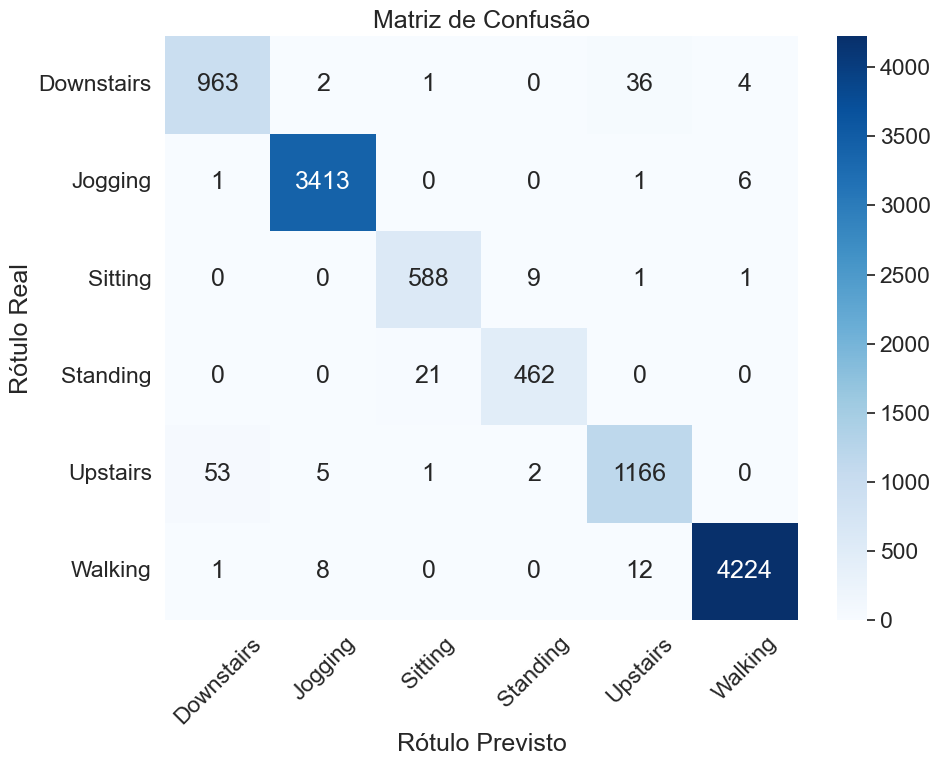

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

LABELS = ['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']

# Etapa 2 – Converte de one-hot para rótulo numérico
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(predictions, axis=1)

# Etapa 3 – Calcula matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Etapa 4 – Exibe a matriz como mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)

plt.title("Matriz de Confusão")
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Previsto')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [45]:
from sklearn.metrics import classification_report

# Rótulos verdadeiros e preditos (conversão de one-hot)
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(predictions, axis=1)

# Rótulos das classes
LABELS = ['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']

# Relatório completo por classe
report = classification_report(y_true, y_pred, target_names=LABELS)
print("Métricas de classificação por classe:\n")
print(report)


Métricas de classificação por classe:

              precision    recall  f1-score   support

  Downstairs       0.95      0.96      0.95      1006
     Jogging       1.00      1.00      1.00      3421
     Sitting       0.96      0.98      0.97       599
    Standing       0.98      0.96      0.97       483
    Upstairs       0.96      0.95      0.95      1227
     Walking       1.00      1.00      1.00      4245

    accuracy                           0.98     10981
   macro avg       0.97      0.97      0.97     10981
weighted avg       0.99      0.98      0.98     10981



**Carregamento do modelo treinado já armazenado**

In [46]:
from tensorflow.keras.models import load_model

# Caminho do modelo salvo (o melhor durante o treinamento)
checkpoint_path = './checkpoint/best_model.h5'

# Carrega o modelo treinado
model = load_model(checkpoint_path)

# Avalia novamente (opcional)
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Modelo carregado — Accuracy: {acc:.4f} | Loss: {loss:.4f}')

# Pode usar diretamente para predições:
#predictions = model.predict(X_test)


Modelo carregado — Accuracy: 0.9850 | Loss: 0.0943


# Exportar o modelo

In [47]:
import shutil
from pathlib import Path
import tensorflow as tf

# Caminho do modelo treinado salvo
MODEL_PATH = Path('./checkpoint/best_model.h5')
TFLITE_PATH = Path('./model.tflite')
FLUTTER_ASSET_PATH = Path('./APP/har_app/assets/model.tflite')

# Carregar o modelo Keras
model = tf.keras.models.load_model(MODEL_PATH)

timesteps = model.input_shape[1]
features = model.input_shape[2]

# Tracar com entrada de batch fixo = 1 (tamanho real no dispositivo)
@tf.function(input_signature=[tf.TensorSpec([1, timesteps, features], tf.float32)])
def infer(x):
    return model(x, training=False)

concrete_func = infer.get_concrete_function()

converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func], model)

# Opcao 4: habilita fallback com Select TF Ops (aceita TensorList/Flex)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = True
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Realiza a conversao
try:
    tflite_model = converter.convert()
except Exception as e:
    raise RuntimeError(
        'Falha na conversao para TFLite com SELECT_TF_OPS habilitado.\n'
        f'Erro original: {e}'
    )

# Verificacao informativa (nao bloqueia mais, pois Flex e esperado na opcao 4)
flex_markers = [b'Flex', b'TensorListReserve', b'TensorListStack', b'TensorListSetItem', b'SELECT_TF_OPS']
found_markers = [m.decode('utf-8') for m in flex_markers if m in tflite_model]

# Salva o arquivo local
TFLITE_PATH.write_bytes(tflite_model)

# Copia automaticamente para o app Flutter
FLUTTER_ASSET_PATH.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(TFLITE_PATH, FLUTTER_ASSET_PATH)

if found_markers:
    print(f'Aviso: o .tflite contem ops Flex/Select TF Ops: {found_markers}')
    print('Isso e esperado ao usar a opcao 4 (SELECT_TF_OPS).')
else:
    print('Modelo TFLite exportado sem marcadores Flex detectados.')

print(f'Entrada esperada: [1, {timesteps}, {features}]')
print(f'Salvo em: {TFLITE_PATH.resolve()}')
print(f'Copiado para: {FLUTTER_ASSET_PATH.resolve()}')

2026-05-12 22:11:32.803826: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-05-12 22:11:32.803907: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session


Aviso: o .tflite contem ops Flex/Select TF Ops: ['TensorListSetItem']
Isso e esperado ao usar a opcao 4 (SELECT_TF_OPS).
Entrada esperada: [1, 200, 3]
Salvo em: /Users/marcos/Documents/Cursos/Embarcados/entrega 06Maio/model.tflite
Copiado para: /Users/marcos/Documents/Cursos/Embarcados/entrega 06Maio/APP/har_app/assets/model.tflite


W0000 00:00:1778634693.133213  423186 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1778634693.133229  423186 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-05-12 22:11:33.191966: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3064] Estimated count of arithmetic ops: 0.152 M  ops, equivalently 0.076 M  MACs


In [48]:
import os

# Caminho do modelo salvo (.h5 e .tflite)
keras_path = './checkpoint/final_model.h5'
tflite_path = './model.tflite'

# Tamanhos em MB
print("Tamanho do modelo .h5: {:.2f} MB".format(os.path.getsize(keras_path) / 1024**2))
print("Tamanho do modelo .tflite: {:.2f} MB".format(os.path.getsize(tflite_path) / 1024**2))


Tamanho do modelo .h5: 0.67 MB
Tamanho do modelo .tflite: 0.12 MB


In [49]:
import numpy as np
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path='model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Entrada:')
for d in input_details:
    print(f"  nome: {d['name']}, shape: {d['shape']}, tipo: {d['dtype']}")

print('\nSaida:')
for d in output_details:
    print(f"  nome: {d['name']}, shape: {d['shape']}, tipo: {d['dtype']}")

# Teste de inferencia ponta a ponta com entrada dummy
in_shape = input_details[0]['shape'].copy()
in_shape = [1 if x == -1 else int(x) for x in in_shape]

if len(in_shape) == 3 and in_shape[2] == 3:
    dummy = np.zeros(in_shape, dtype=np.float32)
elif len(in_shape) == 2:
    dummy = np.zeros(in_shape, dtype=np.float32)
elif len(in_shape) == 4 and in_shape[2] == 3 and in_shape[3] == 1:
    dummy = np.zeros(in_shape, dtype=np.float32)
else:
    raise RuntimeError(f'Formato de entrada inesperado para teste: {in_shape}')

interpreter.set_tensor(input_details[0]['index'], dummy)
interpreter.invoke()

out = interpreter.get_tensor(output_details[0]['index'])
print('\nInferencia OK.')
print(f'Shape da saida no teste: {out.shape}')

Entrada:
  nome: x, shape: [  1 200   3], tipo: <class 'numpy.float32'>

Saida:
  nome: Identity, shape: [1 6], tipo: <class 'numpy.float32'>

Inferencia OK.
Shape da saida no teste: (1, 6)
